In [1]:
# ============================================================
# RESULTS PART: TCGA-BRCA Model Evaluation
# ============================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, cohen_kappa_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import learning_curve, StratifiedKFold

# Create folder to save result figures
os.makedirs("results_figures", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# 1. Load Preprocessed Data and Trained Models
# ============================================================

# Load preprocessed dataset
with open("preprocessed_data.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

le = data["label_encoder"]
class_names = list(le.classes_)
n_classes = len(class_names)

# Load trained models
with open("trained_models.pkl", "rb") as f:
    models_output = pickle.load(f)

best_models = {
    "Bagged Elastic Net": models_output["Bagged_Elastic_Net"],
    "SVM": models_output["SVM"],
    "Random Forest": models_output["Random_Forest"],
    "XGBoost": models_output["XGBoost"]
}

print("Data and trained models loaded successfully.")
print("Class names:", class_names)
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

c:\Users\XINYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\XINYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\XINYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEnc

Data and trained models loaded successfully.
Class names: ['Basal', 'Her2', 'LumA', 'LumB', 'Normal']
X_train: (1695, 417)
X_val: (118, 417)
X_test: (197, 417)


c:\Users\XINYA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# ============================================================
# Fix sklearn version compatibility issue for LogisticRegression
# ============================================================

from sklearn.linear_model import LogisticRegression

def fix_logistic_regression_multiclass(model):
    """
    Fix missing multi_class attribute caused by sklearn version mismatch
    when loading LogisticRegression models from pickle.
    """

    # Case 1: Model itself is LogisticRegression
    if isinstance(model, LogisticRegression):
        if not hasattr(model, "multi_class"):
            model.multi_class = "auto"

    # Case 2: BaggingClassifier contains LogisticRegression estimators
    if hasattr(model, "estimators_"):
        for estimator in model.estimators_:
            if isinstance(estimator, LogisticRegression):
                if not hasattr(estimator, "multi_class"):
                    estimator.multi_class = "auto"

    return model


# Apply fix to all loaded models
for model_name in best_models:
    best_models[model_name] = fix_logistic_regression_multiclass(best_models[model_name])

print("Compatibility fix applied successfully.")

Compatibility fix applied successfully.


In [4]:
# ============================================================
# 2. Final Test Set Evaluation
# ============================================================

y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

results = []

for model_name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    # Probability prediction for AUC-ROC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        auc_macro = roc_auc_score(
            y_test_bin,
            y_prob,
            average="macro",
            multi_class="ovr"
        )
    else:
        auc_macro = np.nan
    
    results.append({
        "Model": model_name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision (Macro)": round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall (Macro)": round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "F1-Score (Macro)": round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "AUC-ROC (Macro)": round(auc_macro, 4),
        "Cohen's Kappa": round(cohen_kappa_score(y_test, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4)
    })

df_results = pd.DataFrame(results)

print("Table 9.1: Performance comparison of trained models on the test set")
display(df_results)

# Save table
df_results.to_csv("results_figures/Table_9_1_Model_Performance.csv", index=False)

Table 9.1: Performance comparison of trained models on the test set


,Model,Accuracy (%),Precision (Macro),Recall (Macro),F1-Score (Macro),AUC-ROC (Macro),Cohen's Kappa,MCC
0,Bagged Elastic Net,95.43,0.9471,0.9389,0.9413,0.9942,0.9318,0.9324
1,SVM,90.36,0.9306,0.8189,0.8638,0.9878,0.8497,0.8531
2,Random Forest,86.29,0.9291,0.6876,0.7332,0.9747,0.7813,0.7902
3,XGBoost,91.37,0.9106,0.8529,0.8767,0.9878,0.8689,0.8691


In [5]:
# ============================================================
# 3. Select Best Model Based on Macro F1-Score
# ============================================================

best_model_name = df_results.sort_values(
    by="F1-Score (Macro)", 
    ascending=False
).iloc[0]["Model"]

best_model = best_models[best_model_name]

print("Best model selected:", best_model_name)

Best model selected: Bagged Elastic Net


In [6]:
# ============================================================
# 4. Classification Report for Best Model
# ============================================================

y_pred_best = best_model.predict(X_test)

report = classification_report(
    y_test,
    y_pred_best,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

df_classification_report = pd.DataFrame(report).transpose()

print(f"Classification Report for {best_model_name}")
display(df_classification_report)

# Save classification report
df_classification_report.to_csv("results_figures/Classification_Report_Best_Model.csv")

Classification Report for Bagged Elastic Net


,precision,recall,f1-score,support
Basal,1.000000,1.000000,1.000000,34.000000
Her2,0.882353,0.937500,0.909091,16.000000
LumA,0.989583,0.950000,0.969388,100.000000
LumB,0.863636,0.950000,0.904762,40.000000
Normal,1.000000,0.857143,0.923077,7.000000
accuracy,0.954315,0.954315,0.954315,0.954315
macro avg,0.947115,0.938929,0.941263,197.000000
weighted avg,0.957469,0.954315,0.955006,197.000000


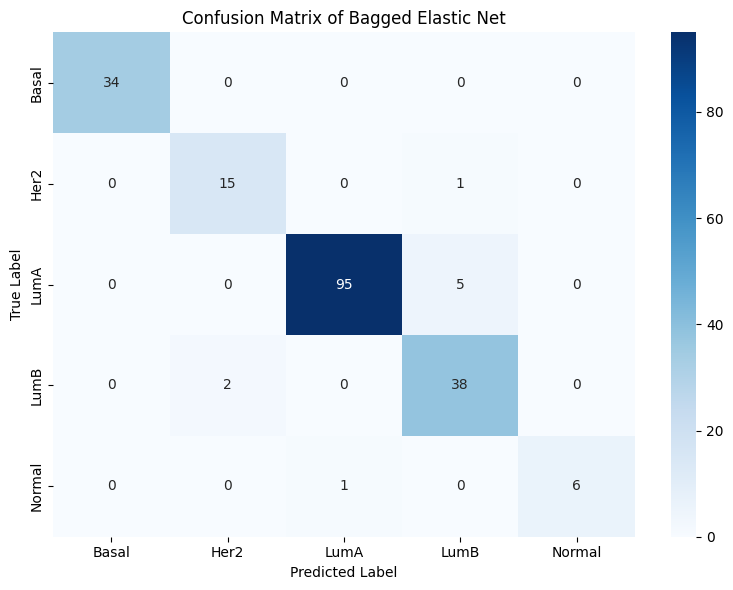

In [7]:
# ============================================================
# 5. Confusion Matrix for Best Model
# ============================================================

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Confusion Matrix of {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("results_figures/Figure_9_1_Confusion_Matrix_Best_Model.png", dpi=300)
plt.show()

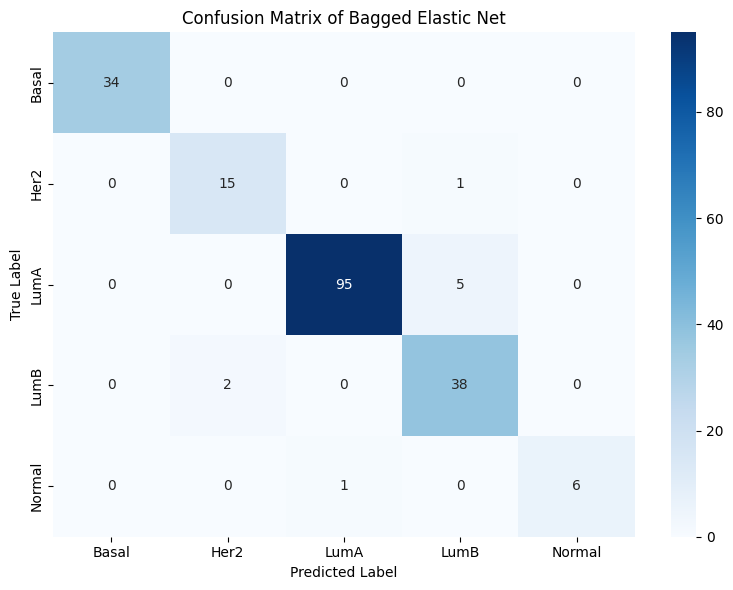

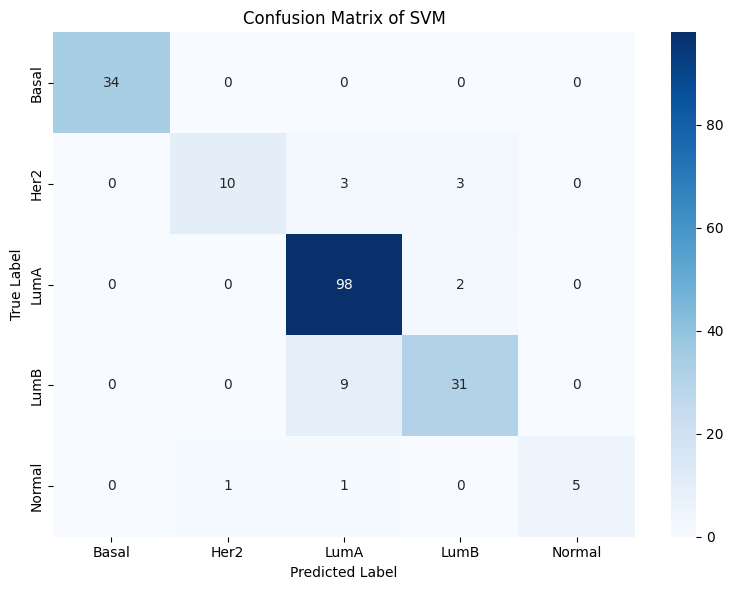

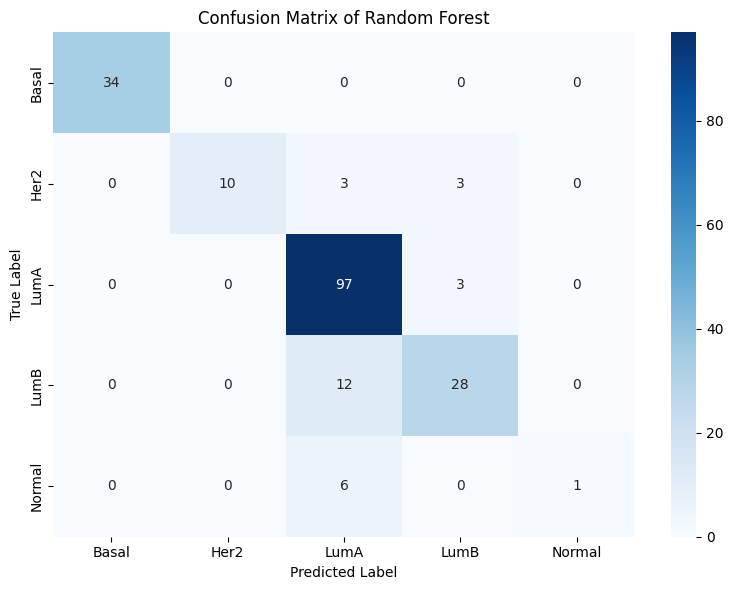

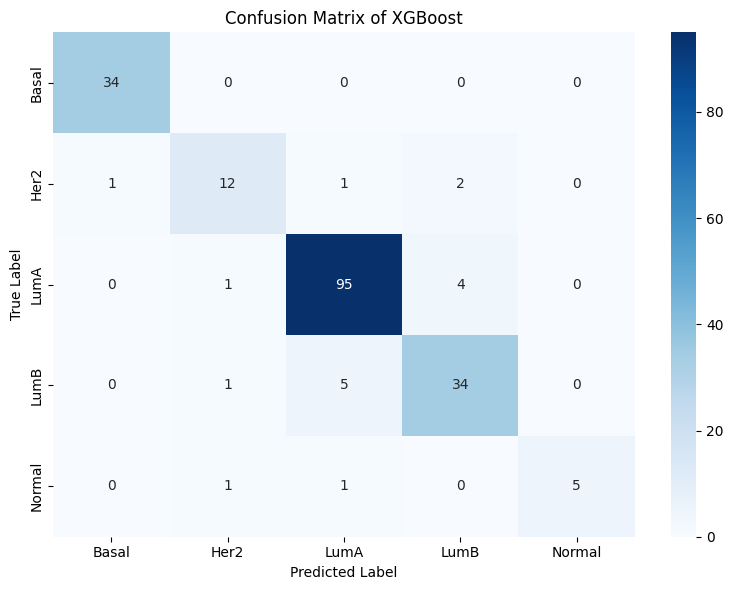

In [8]:
# ============================================================
# 6. Confusion Matrices for All Models
# ============================================================

for model_name, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Confusion Matrix of {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    filename = f"results_figures/Confusion_Matrix_{model_name.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    plt.show()

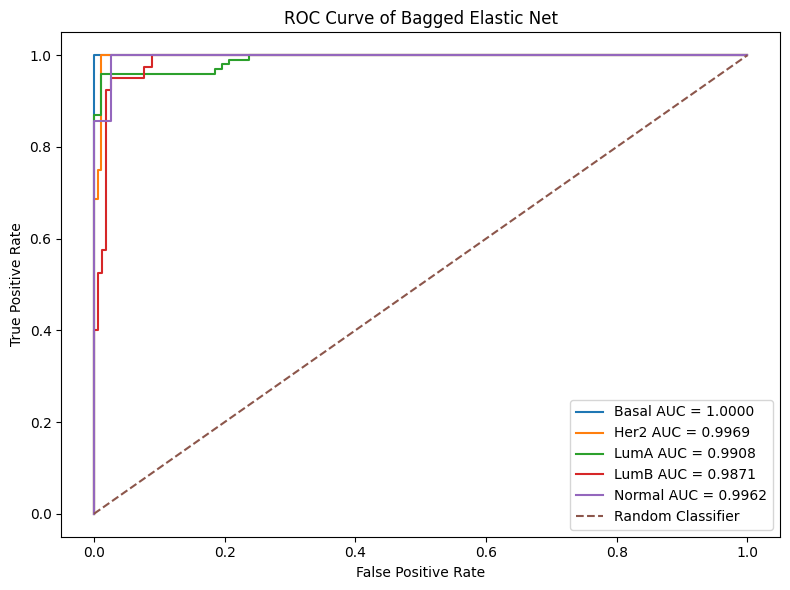

In [9]:
# ============================================================
# 7. Multi-Class ROC Curve for Best Model
# ============================================================

y_prob_best = best_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_best[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} AUC = {roc_auc[i]:.4f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title(f"ROC Curve of {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results_figures/Figure_9_2_ROC_Curve_Best_Model.png", dpi=300)
plt.show()

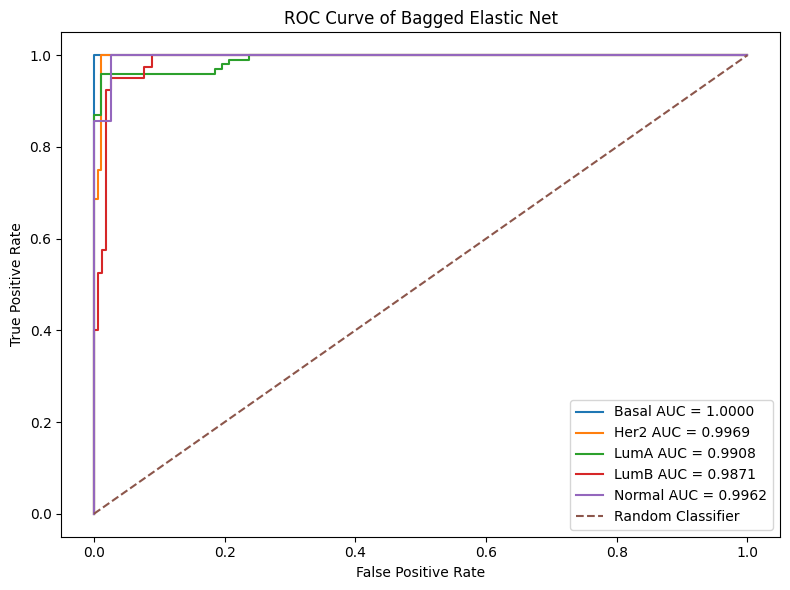

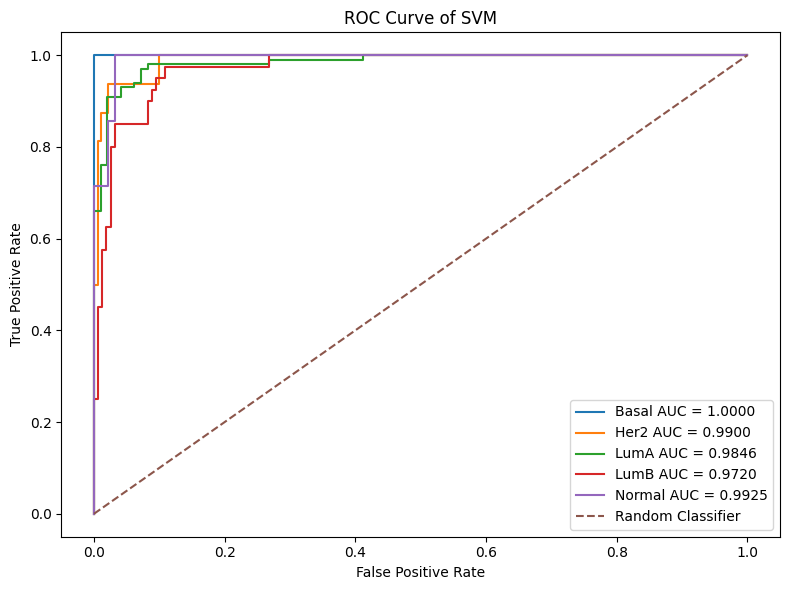

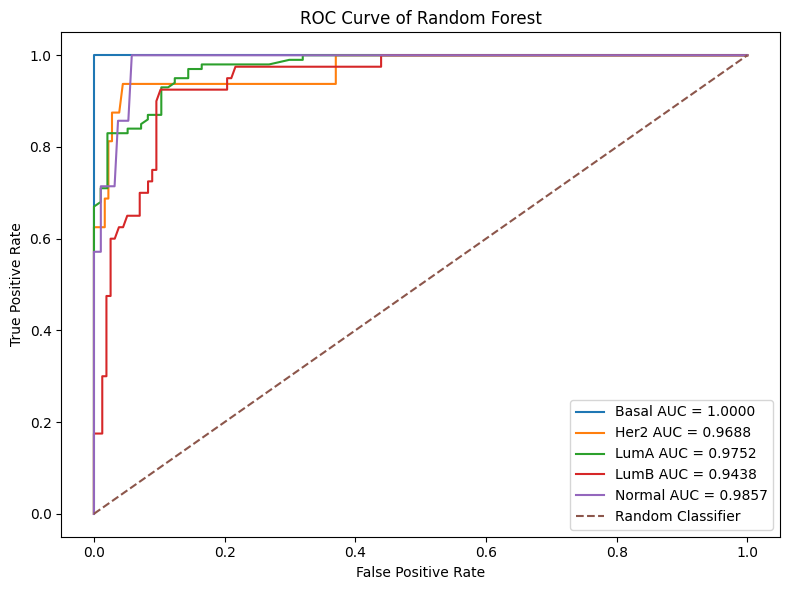

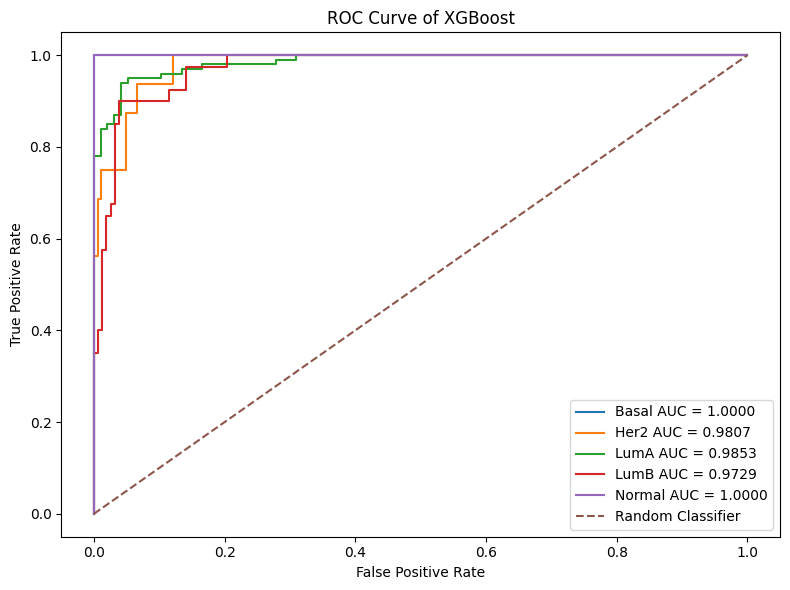

In [10]:
# ============================================================
# 8. ROC Curves for All Models
# ============================================================

for model_name, model in best_models.items():
    if not hasattr(model, "predict_proba"):
        print(f"{model_name} does not support predict_proba. Skipping ROC curve.")
        continue
    
    y_prob = model.predict_proba(X_test)

    plt.figure(figsize=(8, 6))

    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_i = auc(fpr_i, tpr_i)

        plt.plot(
            fpr_i,
            tpr_i,
            label=f"{class_names[i]} AUC = {auc_i:.4f}"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

    plt.title(f"ROC Curve of {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()

    filename = f"results_figures/ROC_Curve_{model_name.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    plt.show()

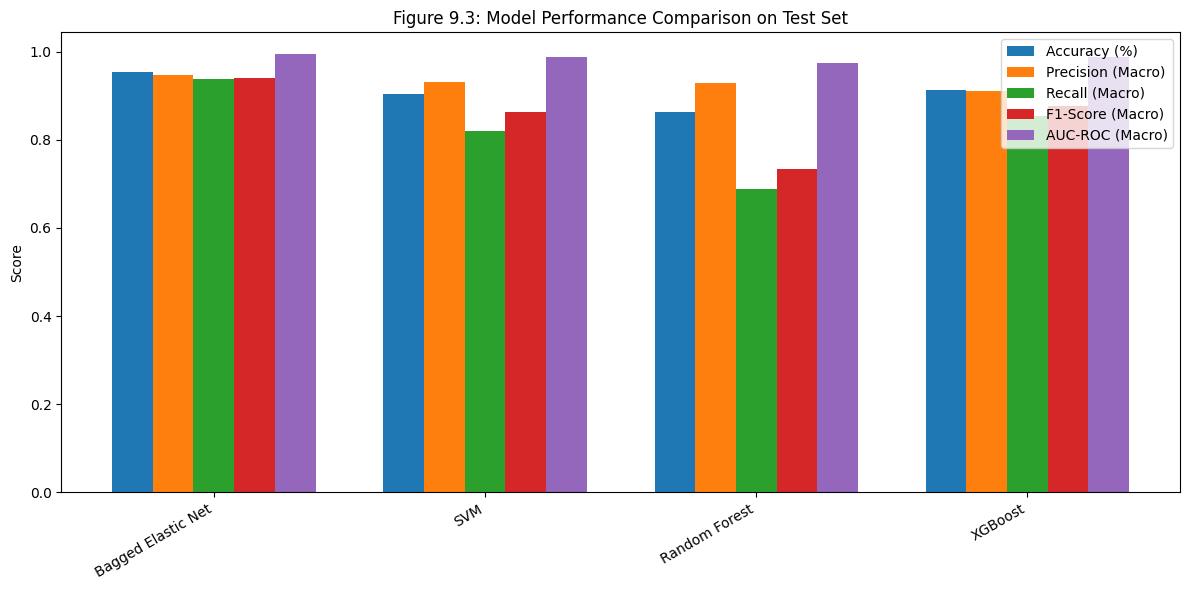

In [11]:
# ============================================================
# 9. Model Performance Bar Chart
# ============================================================

metrics_to_plot = [
    "Accuracy (%)",
    "Precision (Macro)",
    "Recall (Macro)",
    "F1-Score (Macro)",
    "AUC-ROC (Macro)"
]

df_plot = df_results.copy()

# Convert accuracy from percentage to scale 0-1 for fair plotting
df_plot["Accuracy (%)"] = df_plot["Accuracy (%)"] / 100

plt.figure(figsize=(12, 6))

x = np.arange(len(df_plot["Model"]))
width = 0.15

for i, metric in enumerate(metrics_to_plot):
    plt.bar(
        x + i * width,
        df_plot[metric],
        width,
        label=metric
    )

plt.xticks(x + width * 2, df_plot["Model"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Figure 9.3: Model Performance Comparison on Test Set")
plt.legend()
plt.tight_layout()
plt.savefig("results_figures/Figure_9_3_Model_Performance_Comparison.png", dpi=300)
plt.show()

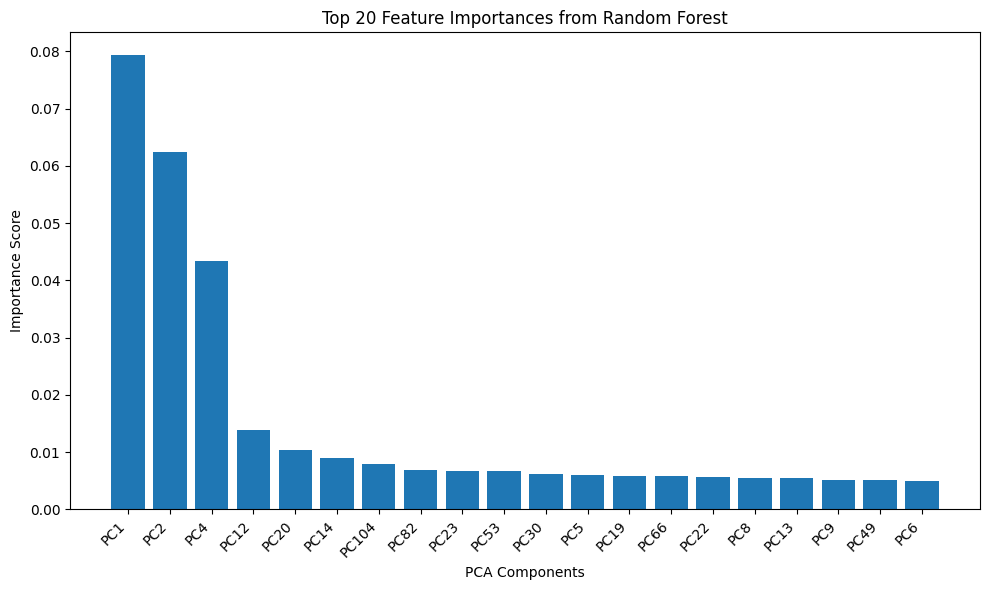

In [12]:
# ============================================================
# 10. Feature Importance Plot - Random Forest
# ============================================================

rf_model = best_models["Random Forest"]

if hasattr(rf_model, "feature_importances_"):
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1][:20]

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(indices)), importances[indices])
    plt.xticks(
        range(len(indices)),
        [f"PC{i+1}" for i in indices],
        rotation=45,
        ha="right"
    )

    plt.title("Top 20 Feature Importances from Random Forest")
    plt.xlabel("PCA Components")
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.savefig("results_figures/Figure_9_4_RF_Feature_Importance.png", dpi=300)
    plt.show()
else:
    print("Random Forest model does not have feature_importances_.")

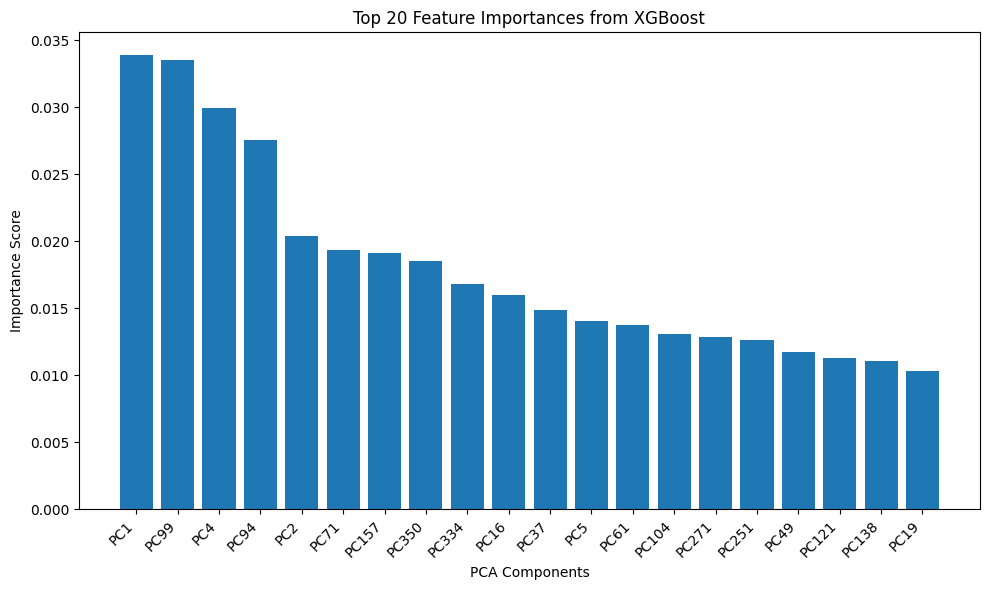

In [13]:
# ============================================================
# 11. Feature Importance Plot - XGBoost
# ============================================================

xgb_model = best_models["XGBoost"]

if hasattr(xgb_model, "feature_importances_"):
    importances = xgb_model.feature_importances_
    indices = np.argsort(importances)[::-1][:20]

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(indices)), importances[indices])
    plt.xticks(
        range(len(indices)),
        [f"PC{i+1}" for i in indices],
        rotation=45,
        ha="right"
    )

    plt.title("Top 20 Feature Importances from XGBoost")
    plt.xlabel("PCA Components")
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.savefig("results_figures/Figure_9_5_XGBoost_Feature_Importance.png", dpi=300)
    plt.show()
else:
    print("XGBoost model does not have feature_importances_.")

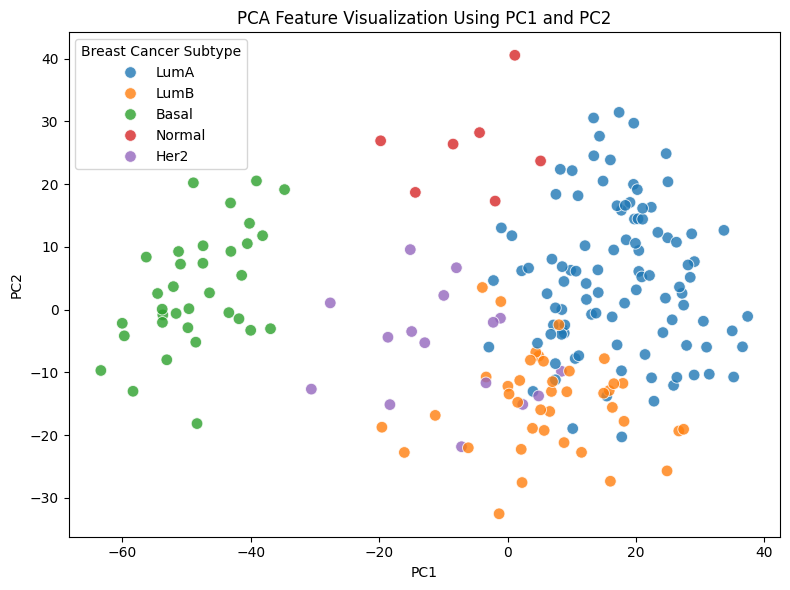

In [14]:
# ============================================================
# Feature Visualization: PCA Components Colored by Class Label
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("results_figures", exist_ok=True)

# Convert test PCA features into DataFrame
df_pca_vis = pd.DataFrame(X_test)

# Add class labels
df_pca_vis["Subtype"] = [class_names[i] for i in y_test]

# Plot first two PCA components
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca_vis,
    x=0,
    y=1,
    hue="Subtype",
    s=70,
    alpha=0.8
)

plt.title("PCA Feature Visualization Using PC1 and PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Breast Cancer Subtype")
plt.tight_layout()
plt.savefig("results_figures/Figure_9_6_PCA_Feature_Visualization_PC1_PC2.png", dpi=300)
plt.show()